In [24]:
!pip install dtreeviz
!apt-get -qq install graphviz

/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


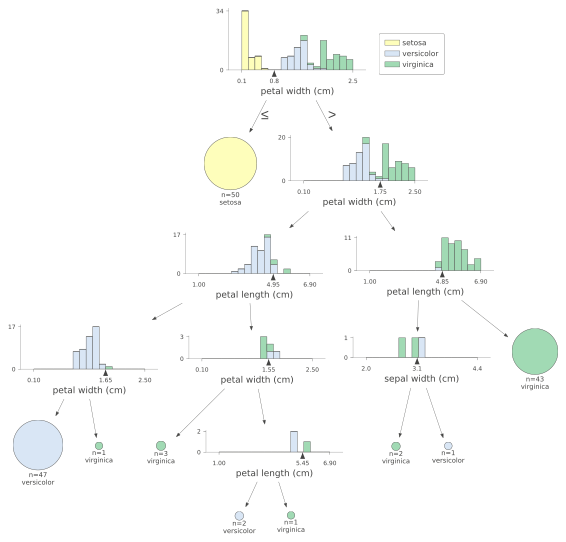

In [41]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

from sklearn import tree
from sklearn.datasets import load_iris
from dtreeviz import model

iris = load_iris()
X_train = iris.data
y_train = iris.target

clas = tree.DecisionTreeClassifier()
clas.fit(X_train, y_train)

m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False
)

viz = m.view()
viz


/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


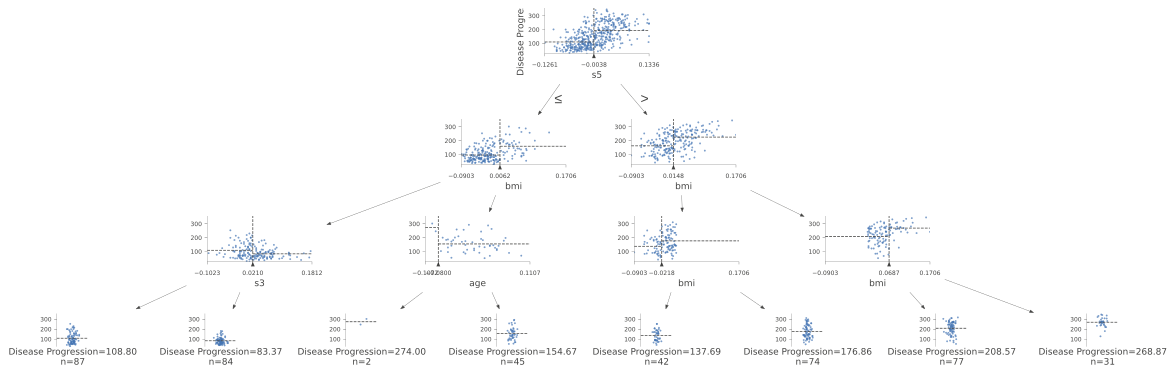

In [42]:
from sklearn.datasets import load_diabetes
from sklearn import tree
from dtreeviz import model   # <-- correct import

# Load dataset
data = load_diabetes()
X_train = data.data
y_train = data.target

# Train Regression Tree
regr = tree.DecisionTreeRegressor(max_depth=3)
regr.fit(X_train, y_train)

# Visualize using the new model API
m = model(
    regr,
    X_train=X_train,
    y_train=y_train,
    target_name='Disease Progression',
    feature_names=data.feature_names,
    ai_chat=False # Disable AI chat by default, can be enabled later if needed
)
viz = m.view()
viz

/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


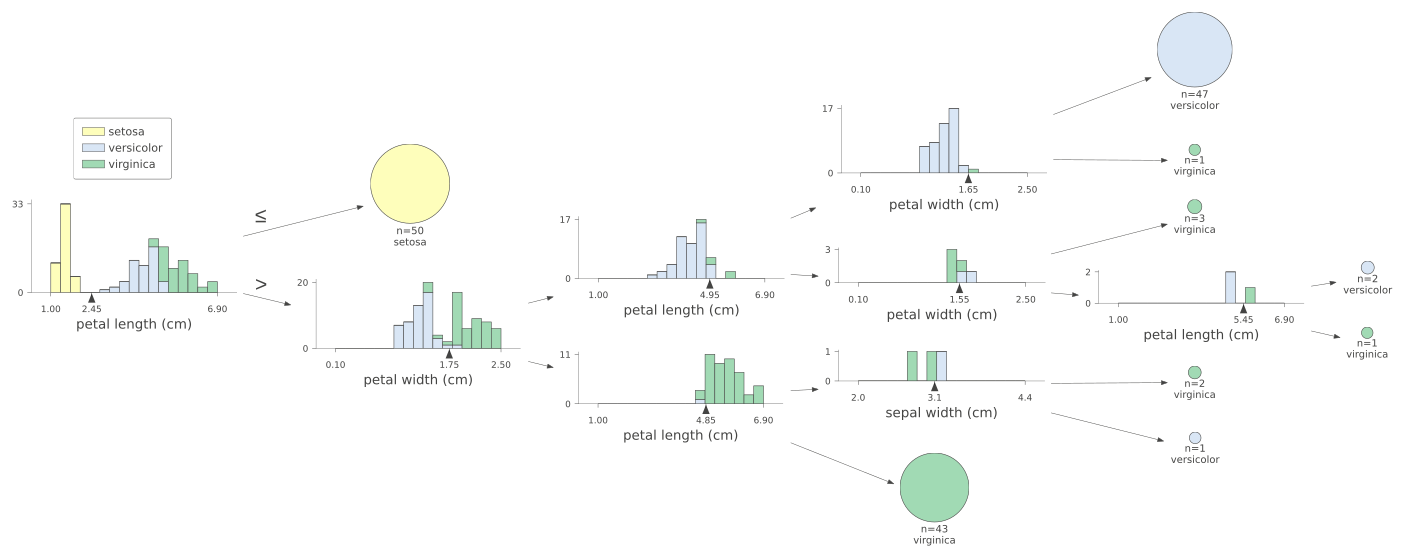

In [43]:
from sklearn.datasets import load_iris
from sklearn import tree
from dtreeviz import model

# Load dataset
iris = load_iris()
X_train = iris.data
y_train = iris.target

# Train model
clas = tree.DecisionTreeClassifier()
clas.fit(X_train, y_train)

# Build model object
m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False   # keep disabled unless OpenAI key provided
)

# Horizontal visualization
viz = m.view(orientation="LR", scale=1.5)
viz


/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


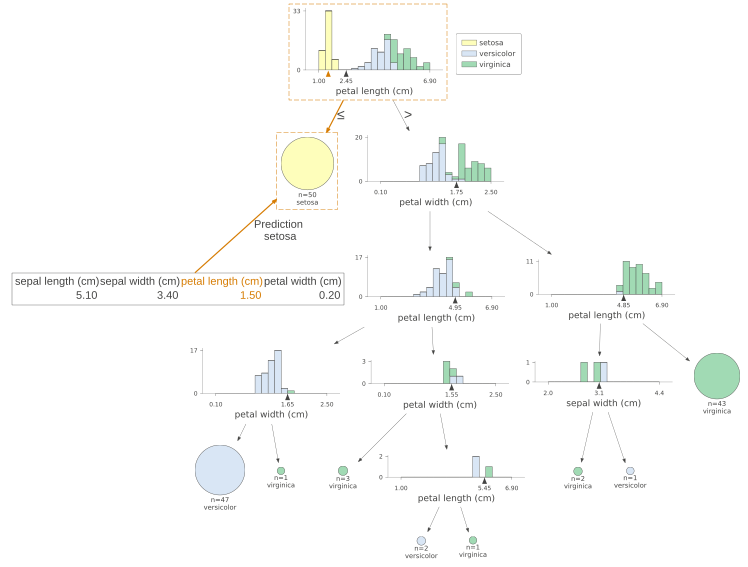

In [62]:
# 4. Show prediction path

# Pick random sample
import numpy as np # Import numpy
X = iris.data[np.random.randint(0, len(iris.data)), :]

m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False
)

viz = m.view(x=X) # Pass X here to highlight prediction path (using lowercase 'x')
viz

/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


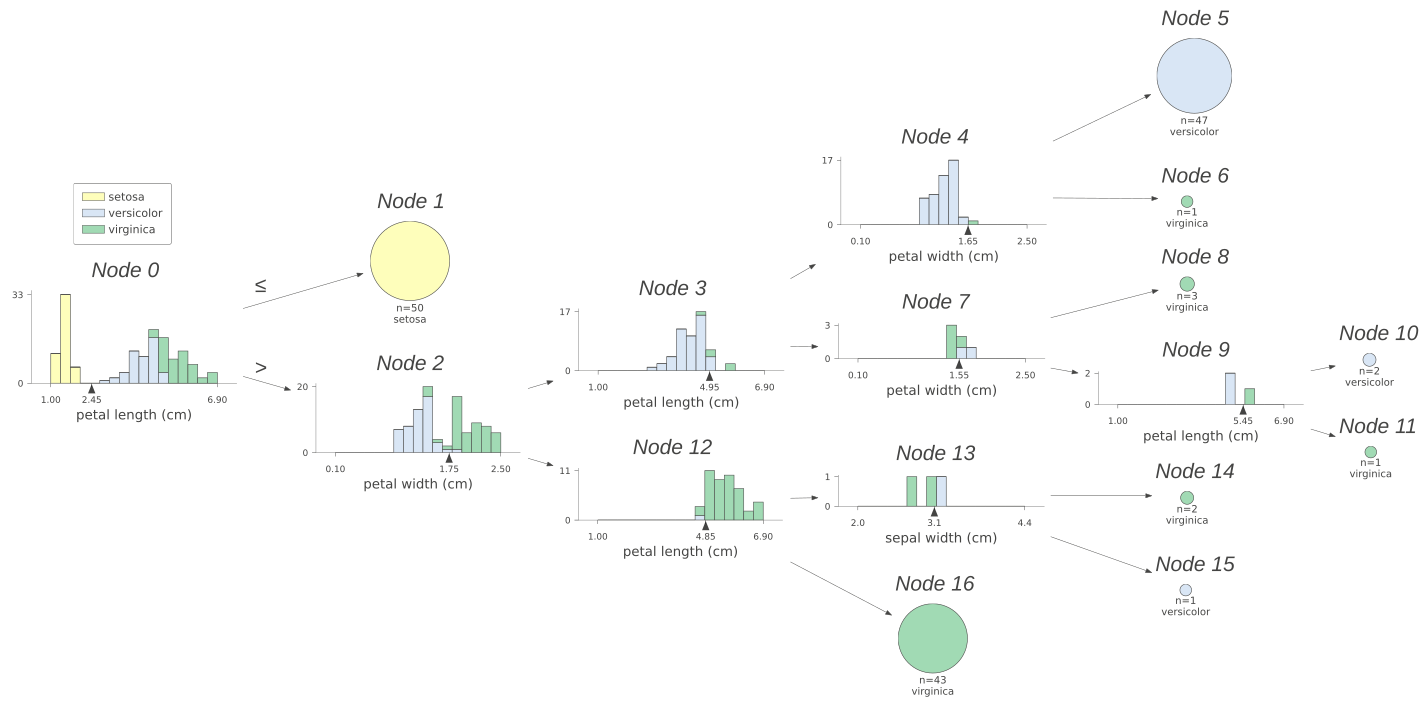

In [49]:
# 5. Show node number

m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False
)

viz = m.view(
    orientation="LR",
    scale=1.5,
    show_node_labels=True   # <-- node numbers
)
viz


/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


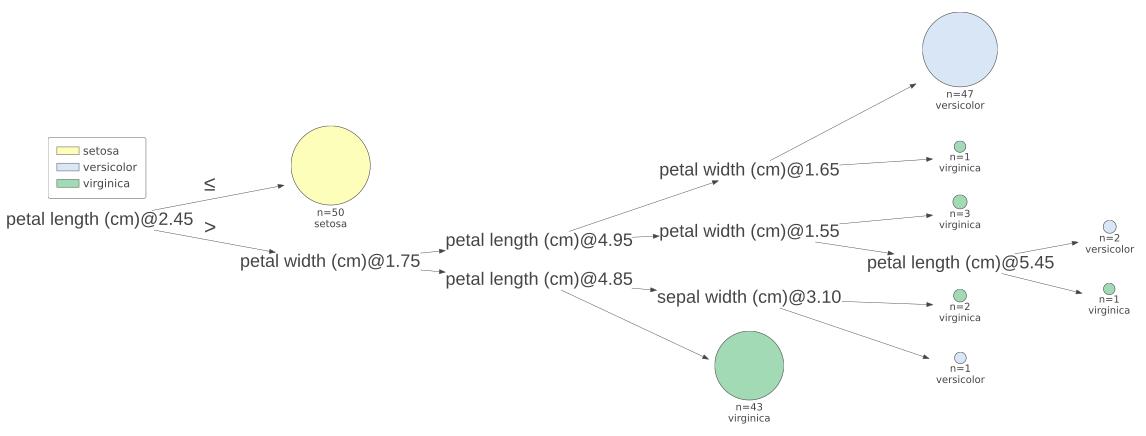

In [50]:
# 6. Without Any graphs

m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False
)

viz = m.view(
    orientation="LR",
    scale=1.5,
    fancy=False       # <-- disables fancy visualization
)
viz

/usr/local/lib/python3.12/dist-packages/dtreeviz/trees.py:828: UserWarning: AI chat was requested, but dtreeviz was not initialized with ai_chat=True. 
AI commentary will be skipped. 
Enable it when instantiating the dtreeviz model using the ai_chat=True parameter.


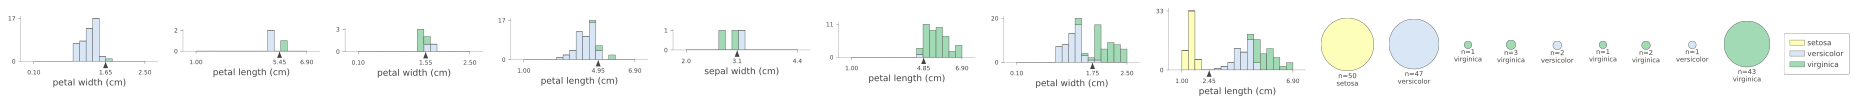

In [60]:
# 7. Show just prediction path, nothing else

X = iris.data[np.random.randint(0, len(iris.data)), :]

m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    ai_chat=False
)

viz = m.view(show_just_path=True)
viz


In [71]:
# 8. Prediction Path in Plain english

explanation = m.explain_prediction_path(X)

print(explanation)

petal length (cm) < 2.45



In [68]:
# 9. Feature Importance

explanation = m.explain_prediction_path(X)

print(explanation)


petal length (cm) < 2.45



/tmp/ipython-input-3267012336.py:16: DeprecationWarning: rtreeviz_univar() function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.rtree_feature_space(...)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


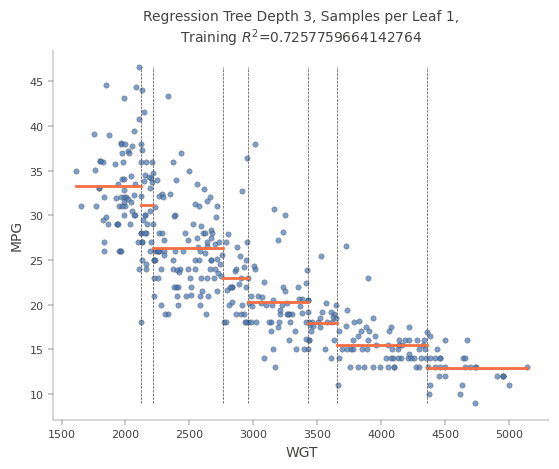

In [80]:
# 10. Univariate Regression

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from dtreeviz import rtreeviz_univar   # correct import

df_cars = pd.read_csv("cars.csv")  # must exist in your Colab
X = df_cars[['WGT']]
y = df_cars['MPG']

dt = DecisionTreeRegressor(max_depth=3, criterion="absolute_error")
dt.fit(X, y)

fig, ax = plt.subplots()
rtreeviz_univar(dt, X, y, 'WGT', 'MPG', ax=ax)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


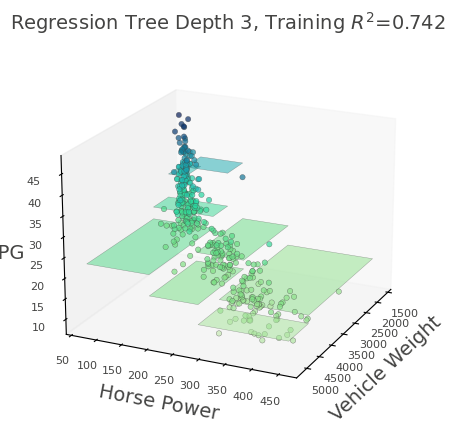

In [82]:
# 11. 3-D Regression

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import DecisionTreeRegressor
from dtreeviz import model   # Import the new model API

df_cars = pd.read_csv("cars.csv")

X = df_cars[['WGT','ENG']]
y = df_cars['MPG']

dt = DecisionTreeRegressor(max_depth=3, criterion="absolute_error")
dt.fit(X, y)

# Visualize using the new model API
m = model(
    dt,
    X_train=X,
    y_train=y,
    feature_names=['Vehicle Weight', 'Horse Power'],
    target_name='MPG'
)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

m.rtree_feature_space3D(
    ax=ax,
    fontsize=14,
    elev=20,
    azim=25,
    dist=8.2,
    show={'splits','title'}
)

plt.show()

In [78]:
!wget -nc https://raw.githubusercontent.com/parrt/dtreeviz/master/data/cars.csv

--2025-12-30 09:05:37--  https://raw.githubusercontent.com/parrt/dtreeviz/master/data/cars.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5996 (5.9K) [text/plain]
Saving to: ‘cars.csv’

cars.csv            100%[===================>]   5.86K  --.-KB/s    in 0s      

2025-12-30 09:05:37 (65.2 MB/s) - ‘cars.csv’ saved [5996/5996]

